In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('/PyAi/Smartphone.csv')
df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


In [6]:
df.columns.tolist()

['User_ID',
 'Age',
 'Gender',
 'Occupation',
 'Device_Type',
 'Daily_Phone_Hours',
 'Social_Media_Hours',
 'Work_Productivity_Score',
 'Sleep_Hours',
 'Stress_Level',
 'App_Usage_Count',
 'Caffeine_Intake_Cups',
 'Weekend_Screen_Time_Hours']

In [7]:
cat_cols=['Age','Gender','Occupation','Device_Type']

for col in cat_cols:
    labels = df[col].dropna().unique()
    mapping = {label: i for i , label in enumerate(labels)}
    df[col] = df[col].map(mapping

_IncompleteInputError: incomplete input (2758366272.py, line 6)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

In [10]:
corr = df.corr(numeric_only=True)
corr['Stress_Level'].sort_values(ascending=False)

Stress_Level                 1.000000
Work_Productivity_Score      0.009786
Sleep_Hours                  0.004691
Weekend_Screen_Time_Hours    0.002671
Caffeine_Intake_Cups         0.001718
App_Usage_Count             -0.001272
Age                         -0.001512
Social_Media_Hours          -0.002721
Daily_Phone_Hours           -0.002762
Name: Stress_Level, dtype: float64

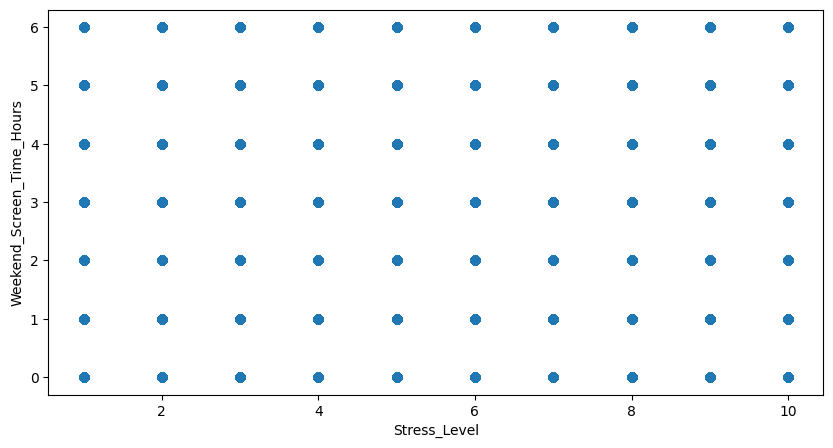

In [11]:
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(df['Stress_Level'], df['Caffeine_Intake_Cups'])
ax.set_xlabel('Stress_Level')
ax.set_ylabel('Weekend_Screen_Time_Hours')
plt.show()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
Age,1.000000,0.006147,-0.005589,-0.003480,-0.000640,-0.001512,-0.009490,-0.005242,0.003127
Daily_Phone_Hours,0.006147,1.000000,0.000591,-0.002404,-0.003434,-0.002762,0.004670,0.006465,-0.003123
Social_Media_Hours,-0.005589,0.000591,1.000000,0.003625,-0.000871,-0.002721,0.001831,0.009161,-0.008570
Work_Productivity_Score,-0.003480,-0.002404,0.003625,1.000000,0.003243,0.009786,0.001125,0.001253,-0.005343
Sleep_Hours,-0.000640,-0.003434,-0.000871,0.003243,1.000000,0.004691,0.000999,0.004251,-0.006457
Stress_Level,-0.001512,-0.002762,-0.002721,0.009786,0.004691,1.000000,-0.001272,0.001718,0.002671
App_Usage_Count,-0.009490,0.004670,0.001831,0.001125,0.000999,-0.001272,1.000000,-0.000096,-0.000530
Caffeine_Intake_Cups,-0.005242,0.006465,0.009161,0.001253,0.004251,0.001718,-0.000096,1.000000,0.002682
Weekend_Screen_Time_Hours,0.003127,-0.003123,-0.008570,-0.005343,-0.006457,0.002671,-0.000530,0.002682,1.000000


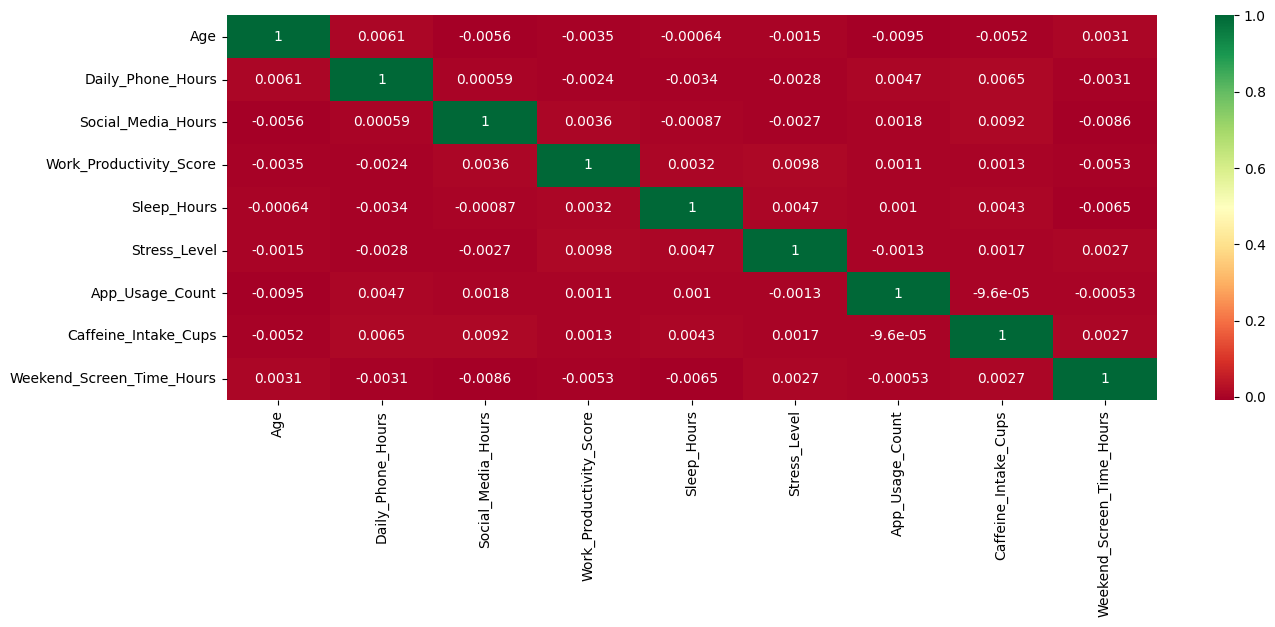

In [12]:
plt.figure(figsize=(15,5))
c = df.corr(numeric_only=True)
sns.heatmap(c, cmap="RdYlGn", annot=True)
c

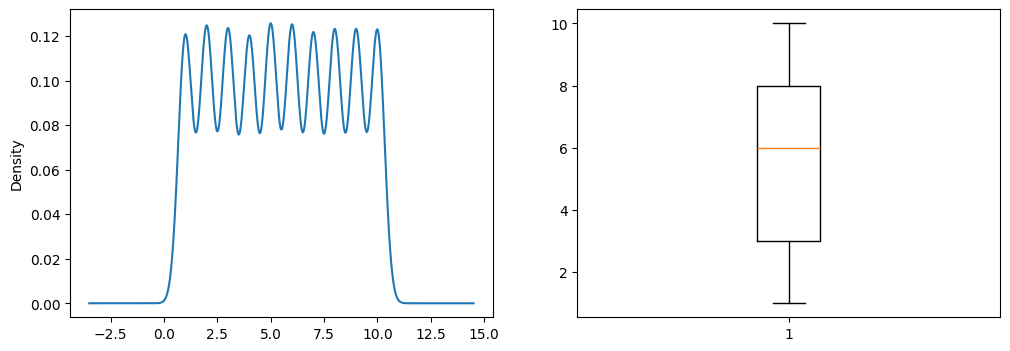

In [13]:
f = plt.figure(figsize=(12,4))
f.add_subplot(1,2,1)
df['Stress_Level'].plot(kind='kde')
f.add_subplot(1,2,2)
plt.boxplot(df['Stress_Level'])
plt.show()

In [14]:
#MULTIPLE LINIER REGRESSION
X = df[["Work_Productivity_Score", "Sleep_Hours","Weekend_Screen_Time_Hours","Caffeine_Intake_Cups"]].to_numpy(dtype=float)
y = df[["Stress_Level"]].to_numpy(dtype=float)  # bentuk (n,1)

n = X.shape[0]
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (50000, 4)
Shape y: (50000, 1)


In [15]:
# Tambahkan kolom 1 untuk intercept (bias)
X_b = np.c_[np.ones((n, 1)), X]  
print("Shape X_b:", X_b.shape)

Shape X_b: (50000, 5)


In [16]:
# Hitung koefisien beta
beta = np.linalg.inv(X_b.T @ X_b) @ (X_b.T @ y)

# simpan model
import pickle

with open("model_regresi.pkl","wb") as f:
    pickle.dump(beta, f)

# ambil nilai koefisien
b0, b1, b2, b3, b4 = beta.flatten()

print("Intercept (b0):", b0)
print("Koef work_productivity_score (b1):", b1)
print("Koef sleep_hours (b2):", b2)
print("Koef weekend_screen_time_hours (b3):", b3)
print("Koef caffeine_intake_cups (b4):", b4)

print(f"\nPersamaan:")
print(f"Ŷ = {b0:.6f} + {b1:.6f}*(work_productivity_score) + {b2:.6f}*(sleep_hours) + {b3:.6f}*(weekend_screen_time_hours) + {b4:.6f}*(caffeine_intake_cups)")

Intercept (b0): 5.365108911308113
Koef work_productivity_score (b1): 0.009771121722844176
Koef sleep_hours (b2): 0.009250284461778132
Koef weekend_screen_time_hours (b3): 0.002279865174617874
Koef caffeine_intake_cups (b4): 0.0024138730353566603

Persamaan:
Ŷ = 5.365109 + 0.009771*(work_productivity_score) + 0.009250*(sleep_hours) + 0.002280*(weekend_screen_time_hours) + 0.002414*(caffeine_intake_cups)


In [17]:
# Prediksi
y_pred = X_b @ beta  # (n,1)
residual = y - y_pred

In [18]:
# Fungsi evaluasi
def mae(y_true, y_hat):
    return float(np.mean(np.abs(y_true - y_hat)))

def mse(y_true, y_hat):
    return float(np.mean((y_true - y_hat) ** 2))

def rmse(y_true, y_hat):
    return float(np.sqrt(mse(y_true, y_hat)))

def r2_score(y_true, y_hat):
    y_true = np.asarray(y_true)
    y_hat = np.asarray(y_hat)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)
    sse = np.sum((y_true - y_hat) ** 2)
    return float(1 - (sse / sst))

In [19]:
mae_val = mae(y, y_pred)
mse_val = mse(y, y_pred)
rmse_val = rmse(y, y_pred)
r2_val = r2_score(y, y_pred)

print("MAE:", mae_val)
print("MSE:", mse_val)
print("RMSE:", rmse_val)
print("R-squared:", r2_val)

MAE: 2.4965932049397463
MSE: 8.241965621464178
RMSE: 2.8708823768075518
R-squared: 0.00012788135510899412


In [20]:
# Lihat hasil prediksi + residu dalam tabel
out = df.copy()
out["pred_stress_level"] = y_pred.flatten()
out["residu"] = (y - y_pred).flatten()

print(out.head(10))

  User_ID  Age  Gender      Occupation Device_Type  Daily_Phone_Hours  \
0      U1   58    Male    Professional     Android                1.3   
1      U2   25    Male    Professional     Android                1.2   
2      U3   19    Male         Student         iOS                5.3   
3      U4   35  Female  Business Owner         iOS                5.8   
4      U5   33    Male      Freelancer     Android                7.9   
5      U6   32  Female         Student     Android               10.9   
6      U7   26    Male         Student         iOS                5.6   
7      U8   24    Male      Freelancer         iOS                8.5   
8      U9   52  Female  Business Owner     Android                9.4   
9     U10   23  Female         Student         iOS                2.8   

   Social_Media_Hours  Work_Productivity_Score  Sleep_Hours  Stress_Level  \
0                 6.7                        6          8.8             4   
1                 1.5                     

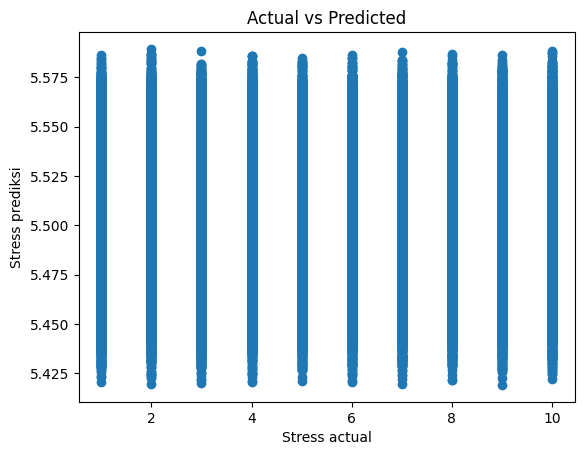

In [21]:
# Plot: Actual vs Predicted
plt.scatter(out["Stress_Level"], out["pred_stress_level"])
plt.title("Actual vs Predicted")
plt.xlabel("Stress actual")
plt.ylabel("Stress prediksi")
plt.show()

In [22]:
out['pred_stress_level_norm'] = (
    out['pred_stress_level'] - out['pred_stress_level'].min()
) / (
    out['pred_stress_level'].max() - out['pred_stress_level'].min()
)

In [23]:
out.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,pred_stress_level,residu,pred_stress_level_norm
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7,5.527387,-1.527387,0.635764
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1,5.492035,-4.492035,0.428451
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3,5.523650,-1.523650,0.613848
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8,5.481043,-2.481043,0.363990
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9,5.491560,-2.491560,0.425664


In [24]:
bins = [0,0.2,0.4,0.6,0.8,1]

labels = [
'sangat rendah',
'rendah',
'sedang',
'tinggi',
'sangat tinggi'
]

out['KategoriStress'] = pd.cut(out['pred_stress_level_norm'], bins=bins, labels=labels)

In [25]:
out[['pred_stress_level_norm', 'KategoriStress']].head(10)

,pred_stress_level_norm,KategoriStress
0,0.635764,tinggi
1,0.428451,sedang
2,0.613848,tinggi
3,0.363990,rendah
4,0.425664,sedang
5,0.660487,tinggi
6,0.587214,sedang
7,0.592511,sedang
8,0.287109,rendah
9,0.021622,sangat rendah


In [26]:
out

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,pred_stress_level,residu,pred_stress_level_norm,KategoriStress
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7,5.527387,-1.527387,0.635764,tinggi
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1,5.492035,-4.492035,0.428451,sedang
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3,5.523650,-1.523650,0.613848,tinggi
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8,5.481043,-2.481043,0.363990,rendah
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9,5.491560,-2.491560,0.425664,sedang
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U49996,44,Male,Business Owner,Android,5.9,5.4,5,6.6,1,11,5,3.0,5.493925,-4.493925,0.439535,sedang
49996,U49997,42,Other,Business Owner,Android,2.9,7.4,9,6.3,2,20,4,6.2,5.535116,-3.535116,0.681093,tinggi
49997,U49998,27,Female,Freelancer,iOS,1.4,2.5,4,6.7,9,39,4,5.1,5.487453,3.512547,0.401579,sedang
49998,U49999,41,Female,Business Owner,iOS,8.9,3.0,6,5.5,2,51,0,9.2,5.495587,-3.495587,0.449279,sedang
